In [1]:
import xarray as xr

# 打开 nc 文件
ds = xr.open_dataset('ERA5_region_t2m_1940_2024_currentyear03_to_nextyear02.nc')

# 查看变量名、坐标维度、属性
print(ds)


<xarray.Dataset> Size: 2MB
Dimensions:    (region_id: 237, year: 85, month: 12)
Coordinates:
  * region_id  (region_id) int64 2kB 0 1 2 3 4 5 6 ... 231 232 233 234 235 236
  * year       (year) int64 680B 1940 1941 1942 1943 ... 2021 2022 2023 2024
  * month      (month) int64 96B 3 4 5 6 7 8 9 10 11 12 1 2
Data variables:
    t2m        (region_id, year, month) float64 2MB ...


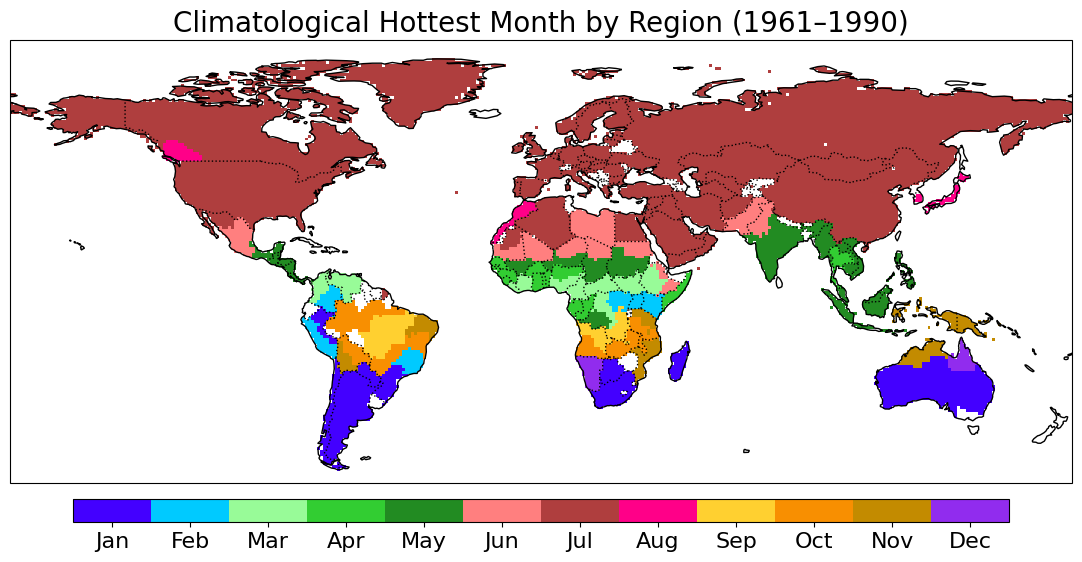

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap

# === Step 1: 加载区域温度数据 ===
ds = xr.open_dataset('ERA5_region_t2m_1940_2024_currentyear03_to_nextyear02.nc')

# === Step 2: 调整 month 顺序 ===
# 获取现有 month
original_months = ds['month'].values  # 例如 [3, 4, ..., 12, 1, 2]

# 生成目标标准顺序 1-12
target_months = np.arange(1, 13)

# 计算新排序索引
sorted_indices = [np.where(original_months == m)[0][0] for m in target_months]

# 重新排序数据
ds_sorted = ds.isel(month=sorted_indices).assign_coords(month=target_months)

# === Step 3: 计算1961-1990气候态 ===
climatology = ds_sorted["t2m"].sel(year=slice(1961, 1990)).mean(dim="year")

# 每个区域最热的月份（1~12）
hottest_month = climatology.argmax(dim="month") + 1  # 从1开始计数

# === Step 4: 加载 region mask 并映射 hottest_month 到地理网格 ===
region_mask_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")
region_mask = region_mask_ds["region_id"]  # (lat, lon)

# 创建映射数组，初始化为 NaN
hottest_month_map = np.full(region_mask.shape, np.nan)

# 将 hottest_month 映射到地图网格上
region_ids = hottest_month.region_id.values
for i, rid in enumerate(region_ids):
    hottest_val = hottest_month.sel(region_id=rid).item()
    hottest_month_map[region_mask.values == rid] = hottest_val

# === Step 5: 可视化 ===

# 自定义月份颜色
month_colors = [
    "#4300FF", "#00CAFF", "#98FB98",  # 1月, 2月, 3月
    "#32CD32", "#228B22", "#FF7F7F",  # 4月, 5月, 6月
    "#AF3E3E", "#FF0088", "#FFD030",  # 7月, 8月, 9月
    "#F88F01", "#C38B00", "#912CEE"   # 10月, 11月, 12月
]
cmap = ListedColormap(month_colors)

# 创建地图图像
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

mesh = ax.pcolormesh(
    region_mask.longitude, region_mask.latitude,
    hottest_month_map,
    cmap=cmap,
    vmin=1, vmax=13,
    transform=ccrs.PlateCarree()
)

# 地图细节
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
ax.set_title("Climatological Hottest Month by Region (1961–1990)", fontsize=20)

# 设置 colorbar
cbar = plt.colorbar(mesh, orientation="horizontal", pad=0.03, shrink=0.8, aspect=40)
cbar.set_ticks(np.arange(1.5, 13.5))
cbar.set_ticklabels([
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])
cbar.ax.tick_params(labelsize=16)
# cbar.set_label("Hottest Month")

plt.tight_layout()
plt.savefig('FigS1_warmest_month_on_19611990.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
import xarray as xr
import numpy as np

# === 1. 读取温度数据并调整 month 顺序 ===
ds = xr.open_dataset('ERA5_region_t2m_1940_2024_currentyear03_to_nextyear02.nc')

# 重新排序 month
original_months = ds['month'].values
target_months = np.arange(1, 13)
sorted_indices = [np.where(original_months == m)[0][0] for m in target_months]

ds_sorted = ds.isel(month=sorted_indices).assign_coords(month=target_months)

# === 2. 计算1961-1990气候态，并确定最热月份 ===
climatology = ds_sorted["t2m"].sel(year=slice(1961, 1990)).mean(dim="year")

# 最热月份 (region_id)，范围1-12
hottest_month = climatology.argmax(dim="month") + 1

# === 3. 构建新Dataset并保存 ===
hottest_ds = xr.Dataset(
    {
        "hottest_month": ("region_id", hottest_month.data)
    },
    coords={
        "region_id": ds_sorted["region_id"]
    }
)

output_path = "region_hottest_month_1961_1990.nc"
hottest_ds.to_netcdf(output_path)
print(f"最热月份已保存：{output_path}")


最热月份已保存：region_hottest_month_1961_1990.nc
